# 04 — Competencia real en el proceso de seleccion

**Proposito.** Cerrar la brecha 1 del documento comparativo, la mas seria de las identificadas: A-H1 es
literalmente una hipotesis sobre competencia y hasta ahora se operacionalizaba unicamente mediante la
modalidad de contratacion como variable indirecta. Este cuaderno incorpora la medida directa —el numero
de oferentes que efectivamente presentaron oferta— y contrasta A-H1 con ella.

**Insumo.** `data/universo_extendido.parquet` (notebook 01), bloque de variables de proceso.

**Etiquetas de objetivo que atiende:** `[A-H1]` (evidencia directa sobre la hipotesis),
`[A-OE04]` (segmentaciones y visualizacion), `[B-OE2]` (variables criticas asociadas a la eficiencia),
`[B-OE3-insumo]` (variables con asociacion relevante que serian candidatas predictoras),
`[CALIDAD]`.

**Advertencia metodologica.** La modalidad de contratacion y el numero de oferentes no son la misma
variable. La hipotesis A-H1 esta formulada sobre modalidades ("licitacion publica frente a modalidades
de menor competencia"), lo que presupone que la modalidad determina la competencia. Ese presupuesto se
somete a prueba en la seccion 2 antes de usar la competencia como contraste.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


In [2]:
df = pd.read_parquet(DIR_DATA / "universo_extendido.parquet")
obs = df[df["observable"]].copy()
df["licitacion_publica"] = es_licitacion_publica(df["modalidad_de_contratacion"])
obs["licitacion_publica"] = es_licitacion_publica(obs["modalidad_de_contratacion"])
print(f"Universo: {len(df):,} | Observable: {len(obs):,}")
print(f"Contratos con dato de competencia: {int(df['n_oferentes'].notna().sum()):,} "
      f"({df['n_oferentes'].notna().mean()*100:.2f}%)")

Universo: 48,331 | Observable: 19,194
Contratos con dato de competencia: 48,293 (99.92%)


## 1. Distribucion de las variables de competencia en doble lectura

In [3]:
marcar("dist_comp")

VARS = ["n_oferentes", "n_respuestas", "n_invitados", "n_visualizaciones"]
NOMBRES = {"n_oferentes": "Oferentes unicos con oferta", "n_respuestas": "Respuestas al procedimiento",
           "n_invitados": "Proveedores invitados", "n_visualizaciones": "Visualizaciones del proceso"}

filas = []
for c in VARS:
    for etq, x in [("universo_completo", df), ("observable", obs)]:
        v = x[c].dropna()
        filas.append({"variable": NOMBRES[c], "lectura": etq, "N_efectivo": len(v),
                      "media": round(v.mean(), 2), "p25": v.quantile(.25), "mediana": v.median(),
                      "p75": v.quantile(.75), "p90": v.quantile(.90), "max": v.max(),
                      "pct_en_cero": round((v == 0).mean() * 100, 2)})
dist = pd.DataFrame(filas)
print(dist.to_string(index=False))
print()
sp = spearman(df["n_oferentes"], df["n_respuestas"])
print(f"Redundancia entre oferentes unicos y respuestas al procedimiento: Spearman rho = {sp['rho']:.4f} "
      f"(N efectivo {sp['n_efectivo']:,}). Practicamente la misma variable; se usa `n_oferentes`.")

                   variable           lectura  N_efectivo   media    p25  mediana      p75      p90        max  pct_en_cero
Oferentes unicos con oferta universo_completo       48293  6.9500 0.0000   1.0000   6.0000  18.0000   254.0000      29.6700
Oferentes unicos con oferta        observable       19177  8.2700 1.0000   2.0000   8.0000  22.0000   254.0000      24.7500
Respuestas al procedimiento universo_completo       48293  6.9900 0.0000   1.0000   6.0000  18.0000   254.0000      28.9600
Respuestas al procedimiento        observable       19177  8.3000 1.0000   2.0000   8.0000  22.0000   254.0000      24.1900
      Proveedores invitados universo_completo       48293 20.4500 0.0000   0.0000   5.0000  21.0000 7,288.0000      70.0600
      Proveedores invitados        observable       19177 21.5100 0.0000   0.0000  10.0000  34.0000 5,299.0000      65.3200
Visualizaciones del proceso universo_completo       48293 70.3200 0.0000  35.0000 105.0000 194.0000   953.0000      26.7600
Visualiz

In [4]:
marcar("comp_cat")

t = pd.DataFrame({
    "universo_completo": df["competencia_cat"].value_counts().reindex(ETIQ_COMPETENCIA),
    "observable": obs["competencia_cat"].value_counts().reindex(ETIQ_COMPETENCIA),
})
t["universo_pct"] = (t["universo_completo"] / t["universo_completo"].sum() * 100).round(2)
t["observable_pct"] = (t["observable"] / t["observable"].sum() * 100).round(2)
t["diferencia_pp"] = (t["observable_pct"] - t["universo_pct"]).round(2)
print(t.to_string())
print()
print("Hallazgo de calidad: el nivel de competencia mas frecuente del universo es el de CERO oferentes")
print("registrados. No significa que el proceso quedara desierto —todos estos contratos existen y se")
print("firmaron— sino que SECOP no publico el conteo de ofertas para ese procedimiento. Es una brecha de")
print("reporte, no de competencia, y obliga a tratar el cero como categoria propia y no como 'sin ofertas'.")
print()
print("Modalidades donde el conteo de oferentes es cero (top 6 por volumen):")
cero = df[df["n_oferentes"] == 0]["modalidad_de_contratacion"].value_counts().head(6).to_frame("n_cero")
cero["total_modalidad"] = df["modalidad_de_contratacion"].value_counts().reindex(cero.index).values
cero["pct_sin_conteo"] = (cero["n_cero"] / cero["total_modalidad"] * 100).round(1)
print(cero.to_string())

                           universo_completo  observable  universo_pct  observable_pct  diferencia_pp
competencia_cat                                                                                      
0 (sin oferta registrada)              14330        4747       29.6700         24.7500        -4.9200
1 (oferente unico)                      9997        3620       20.7000         18.8800        -1.8200
2-3 (baja)                              7029        2692       14.5500         14.0400        -0.5100
4-9 (media)                             8880        4252       18.3900         22.1700         3.7800
10+ (alta)                              8057        3866       16.6800         20.1600         3.4800

Hallazgo de calidad: el nivel de competencia mas frecuente del universo es el de CERO oferentes
registrados. No significa que el proceso quedara desierto —todos estos contratos existen y se
firmaron— sino que SECOP no publico el conteo de ofertas para ese procedimiento. Es una brecha 

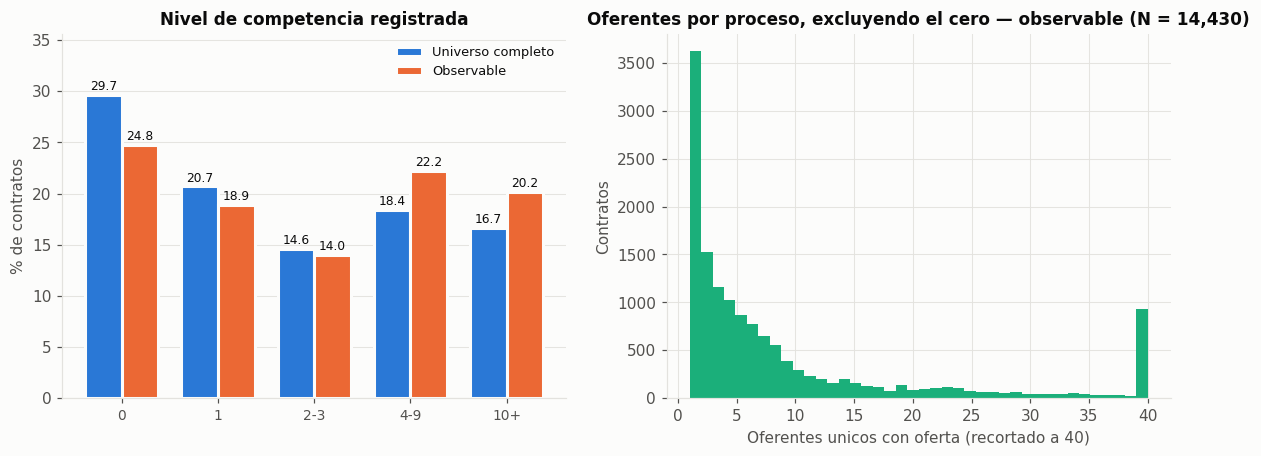

Figura persistida: 04_distribucion_competencia.png


In [5]:
marcar("fig_comp")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
x = np.arange(len(ETIQ_COMPETENCIA)); w = 0.38
ax.bar(x - w/2, t["universo_pct"], w, label="Universo completo", color=PALETA[0],
       edgecolor=SURFACE, linewidth=2)
ax.bar(x + w/2, t["observable_pct"], w, label="Observable", color=PALETA[1],
       edgecolor=SURFACE, linewidth=2)
for i, (a, b) in enumerate(zip(t["universo_pct"], t["observable_pct"])):
    ax.text(i - w/2, a + 0.5, f"{a:.1f}", ha="center", fontsize=8, color=TEXT_1)
    ax.text(i + w/2, b + 0.5, f"{b:.1f}", ha="center", fontsize=8, color=TEXT_1)
ax.set_xticks(x)
ax.set_xticklabels([e.split(" (")[0] for e in ETIQ_COMPETENCIA], fontsize=9)
ax.set_ylabel("% de contratos")
ax.set_ylim(0, max(t["universo_pct"].max(), t["observable_pct"].max()) * 1.2)
ax.set_title("Nivel de competencia registrada", fontsize=11)
ax.legend(fontsize=8.5); ax.xaxis.grid(False); ax.set_axisbelow(True)

ax = axes[1]
v = obs.loc[obs["n_oferentes"].notna() & (obs["n_oferentes"] > 0), "n_oferentes"].clip(upper=40)
ax.hist(v, bins=40, color=PALETA[2])
ax.set_xlabel("Oferentes unicos con oferta (recortado a 40)")
ax.set_ylabel("Contratos")
ax.set_title(f"Oferentes por proceso, excluyendo el cero — observable (N = {len(v):,})", fontsize=11)
ax.set_axisbelow(True)
guardar_mostrar(fig, "04_distribucion_competencia.png")

## 2. ¿La modalidad determina la competencia? Verificacion del presupuesto de A-H1

A-H1 opone la licitacion publica a "modalidades de menor competencia". Antes de aceptar esa
equivalencia hay que comprobarla en el dato: si la licitacion publica no concentrara mas oferentes que
las demas modalidades, la formulacion de la hipotesis seria invalida en su premisa.

In [6]:
marcar("modalidad_competencia")

por_mod = (obs[obs["n_oferentes"].notna()]
           .groupby("modalidad_de_contratacion")
           .agg(n=("n_oferentes", "size"),
                mediana_oferentes=("n_oferentes", "median"),
                media_oferentes=("n_oferentes", "mean"),
                pct_cero_oferentes=("n_oferentes", lambda s: round((s == 0).mean() * 100, 1)),
                pct_4_o_mas=("n_oferentes", lambda s: round((s >= 4).mean() * 100, 1)))
           .sort_values("mediana_oferentes", ascending=False))
por_mod["media_oferentes"] = por_mod["media_oferentes"].round(2)
print(por_mod.to_string())
print()
grupos = {k: v["n_oferentes"].dropna() for k, v in
          obs[obs["n_oferentes"].notna()].groupby("modalidad_de_contratacion")}
kw = kruskal(grupos)
print("Kruskal-Wallis, oferentes por modalidad (subconjunto observable):")
print(" ", resumen_prueba(kw))
print()
r = mann_whitney(obs.loc[obs["licitacion_publica"], "n_oferentes"],
                 obs.loc[~obs["licitacion_publica"], "n_oferentes"],
                 "Licitacion publica", "Otras modalidades")
print("Licitacion publica frente al resto, numero de oferentes:")
print(" ", resumen_prueba(r))

                                                                n  mediana_oferentes  media_oferentes  pct_cero_oferentes  pct_4_o_mas
modalidad_de_contratacion                                                                                                             
Licitación pública Obra Publica                              3947            13.0000          23.3800              2.6000      72.9000
Licitación pública                                            122             6.0000          15.7000              1.6000      65.6000
Mínima cuantía                                               3865             4.0000           5.9800              4.6000      51.7000
Selección Abreviada de Menor Cuantía                         6026             3.0000           6.3300              5.5000      49.8000
Contratación régimen especial (con ofertas)                   442             2.0000           4.5300              5.9000      26.7000
Seleccion Abreviada Menor Cuantia Sin Manifestacion Int

## 3. Relacion entre competencia real y desempeno

In [7]:
marcar("comp_desempeno")

pares = [("n_oferentes", "deslizamiento_plazo_dias"), ("n_oferentes", "desviacion_costo_pct"),
         ("n_invitados", "deslizamiento_plazo_dias"), ("n_invitados", "desviacion_costo_pct"),
         ("n_visualizaciones", "deslizamiento_plazo_dias"), ("n_visualizaciones", "desviacion_costo_pct"),
         ("n_oferentes", "n_modificaciones_total"), ("n_oferentes", "valor_del_contrato")]
filas = []
for a, b in pares:
    for etq, x in [("universo_completo", df), ("observable", obs)]:
        s = spearman(x[a], x[b])
        filas.append({"variable_competencia": a, "variable_desempeno": b, "lectura": etq,
                      "rho_spearman": round(s["rho"], 4), "p": fmt_p(s["p"]),
                      "N_efectivo": s["n_efectivo"], "tamano_efecto": s["efecto"]})
corr_comp = pd.DataFrame(filas)
corr_comp.to_csv(DIR_DATA / "correlaciones_competencia.csv", index=False)
corr_comp

,variable_competencia,variable_desempeno,lectura,rho_spearman,p,N_efectivo,tamano_efecto
0,n_oferentes,deslizamiento_plazo_dias,universo_completo,0.0511,7.18e-23,37123,nulo
1,n_oferentes,deslizamiento_plazo_dias,observable,-0.0004,0.9569,16309,nulo
2,n_oferentes,desviacion_costo_pct,universo_completo,-0.1845,3.89e-115,15020,pequeno
3,n_oferentes,desviacion_costo_pct,observable,-0.2032,2.10e-81,8667,pequeno
4,n_invitados,deslizamiento_plazo_dias,universo_completo,-0.0681,2.18e-39,37123,nulo
5,n_invitados,deslizamiento_plazo_dias,observable,-0.1362,2.17e-68,16309,pequeno
6,n_invitados,desviacion_costo_pct,universo_completo,-0.0281,5.82e-04,15020,nulo
7,n_invitados,desviacion_costo_pct,observable,-0.0359,8.35e-04,8667,nulo
8,n_visualizaciones,deslizamiento_plazo_dias,universo_completo,0.1079,1.28e-96,37123,pequeno
9,n_visualizaciones,deslizamiento_plazo_dias,observable,0.0503,1.29e-10,16309,nulo


In [8]:
marcar("comp_kruskal")

sub = obs[obs["competencia_cat"].notna()]
res = (sub.groupby("competencia_cat")
       .agg(n=("id_contrato", "size"),
            mediana_deslizamiento=("deslizamiento_plazo_dias", "median"),
            n_ef_tiempo=("deslizamiento_plazo_dias", lambda s: int(s.notna().sum())),
            pct_retraso_mayor_30=("deslizamiento_plazo_dias", lambda s: round((s.dropna() > 30).mean()*100, 1)),
            mediana_costo=("desviacion_costo_pct", "median"),
            n_ef_costo=("desviacion_costo_pct", lambda s: int(s.notna().sum())),
            pct_no_entregado=("indice_alcance", lambda s: round((s == "No entregado").mean()*100, 1)),
            mediana_valor=("valor_del_contrato", "median"))
       .reindex(ETIQ_COMPETENCIA))
print(res.to_string())
print()
for var, nombre in [("deslizamiento_plazo_dias", "deslizamiento del plazo"),
                    ("desviacion_costo_pct", "desviacion de costo")]:
    g = {k: v[var].dropna() for k, v in sub.groupby("competencia_cat", observed=True)}
    kw = kruskal(g)
    print(f"Kruskal-Wallis, {nombre} entre niveles de competencia:")
    print(" ", resumen_prueba(kw))
    print()
tab = pd.crosstab(sub["competencia_cat"], sub["indice_alcance"])
cv = cramers_v(tab)
print("Chi-cuadrado, nivel de competencia x indice de alcance:")
print(" ", resumen_prueba(cv))

                              n  mediana_deslizamiento  n_ef_tiempo  pct_retraso_mayor_30  mediana_costo  n_ef_costo  pct_no_entregado    mediana_valor
competencia_cat                                                                                                                                        
0 (sin oferta registrada)  4747                 4.0000         4520               37.1000         0.0000        2502           25.9000 150,000,000.0000
1 (oferente unico)         3620                 1.0000         3264               27.7000        -0.0000        1733           25.1000 210,993,996.0000
2-3 (baja)                 2692                 1.0000         2269               26.2000        -0.0000        1268           19.8000 202,605,787.0000
4-9 (media)                4252                 1.0000         3332               26.4000         0.0000        1757           21.0000 292,008,156.5000
10+ (alta)                 3866                12.0000         2924               41.800

## 4. Contraste de A-H1 con competencia real

**Formulacion operativa.** A-H1 sostiene que a mayor competencia menores desviaciones de costo y tiempo.
Se define competencia alta como cuatro o mas oferentes unicos con oferta y competencia baja como uno a
tres, **excluyendo del contraste los contratos con cero oferentes registrados**, porque el cero es
ausencia de reporte y no ausencia de competencia (seccion 1). Alfa declarado a priori: 0.05.

In [9]:
marcar("h1_competencia")

def contraste_h1(x, etiqueta):
    base = x[x["n_oferentes"].notna() & (x["n_oferentes"] > 0)]
    alta = base[base["n_oferentes"] >= 4]
    baja = base[base["n_oferentes"] < 4]
    out = []
    for var, nombre in [("deslizamiento_plazo_dias", "Deslizamiento del plazo (dias)"),
                        ("desviacion_costo_pct", "Desviacion de costo (%)")]:
        r = mann_whitney(alta[var], baja[var], "Competencia alta (>=4)", "Competencia baja (1-3)")
        out.append({"lectura": etiqueta, "indicador": nombre,
                    "N_alta": r["n_a"], "N_baja": r["n_b"],
                    "mediana_alta": round(r["mediana_a"], 3), "mediana_baja": round(r["mediana_b"], 3),
                    "U": r["U"], "p": fmt_p(r["p"]),
                    "rank_biserial": round(r["rank_biserial"], 4), "tamano_efecto": r["efecto"],
                    "significativo_alfa_005": r["significativo"]})
    return out

h1_comp = pd.DataFrame(contraste_h1(df, "universo_completo") + contraste_h1(obs, "observable"))
print(h1_comp.to_string(index=False))
print()
print("Nota de lectura del signo: el rank-biserial se calcula como 1 - 2U/(n1*n2) con el grupo de")
print("competencia alta en primera posicion. Un valor NEGATIVO significa que el grupo de competencia")
print("alta tiene rangos mayores, es decir, PEOR desempeno en esa dimension.")

          lectura                      indicador  N_alta  N_baja  mediana_alta  mediana_baja               U        p  rank_biserial tamano_efecto  significativo_alfa_005
universo_completo Deslizamiento del plazo (dias)   12058   13540        2.0000        0.0000 90,754,776.5000 4.55e-54        -0.1117       pequeno                    True
universo_completo        Desviacion de costo (%)    4890    5520       -0.0060       -0.0000 11,934,065.5000 1.43e-26         0.1158       pequeno                    True
       observable Deslizamiento del plazo (dias)    6256    5533        3.5000        1.0000 18,876,900.0000 1.58e-17        -0.0907          nulo                    True
       observable        Desviacion de costo (%)    3164    3001       -0.0000       -0.0000  4,363,290.0000 6.87e-09         0.0809          nulo                    True

Nota de lectura del signo: el rank-biserial se calcula como 1 - 2U/(n1*n2) con el grupo de
competencia alta en primera posicion. Un valor NEGATI

In [10]:
marcar("h1_comp_vs_mod")

comparativa = []
for etiqueta, x in [("universo_completo", df), ("observable", obs)]:
    for var, nombre in [("deslizamiento_plazo_dias", "Tiempo"), ("desviacion_costo_pct", "Costo")]:
        rm = mann_whitney(x.loc[x["licitacion_publica"], var],
                          x.loc[~x["licitacion_publica"], var], "Licitacion", "Otras")
        base = x[x["n_oferentes"].notna() & (x["n_oferentes"] > 0)]
        rc = mann_whitney(base.loc[base["n_oferentes"] >= 4, var],
                          base.loc[base["n_oferentes"] < 4, var], "Comp. alta", "Comp. baja")
        comparativa.append({
            "lectura": etiqueta, "dimension": nombre,
            "efecto_MODALIDAD (proxy)": round(rm["rank_biserial"], 4),
            "interpretacion_modalidad": rm["efecto"],
            "efecto_COMPETENCIA_REAL": round(rc["rank_biserial"], 4),
            "interpretacion_competencia": rc["efecto"],
            "N_modalidad": rm["n_a"] + rm["n_b"], "N_competencia": rc["n_a"] + rc["n_b"],
        })
comp_tabla = pd.DataFrame(comparativa)
comp_tabla.to_csv(DIR_DATA / "h1_modalidad_vs_competencia.csv", index=False)
comp_tabla

,lectura,dimension,efecto_MODALIDAD (proxy),interpretacion_modalidad,efecto_COMPETENCIA_REAL,interpretacion_competencia,N_modalidad,N_competencia
0,universo_completo,Tiempo,-0.3798,mediano,-0.1117,pequeno,37155,25598
1,universo_completo,Costo,0.4277,mediano,0.1158,pequeno,15035,10410
2,observable,Tiempo,-0.3862,mediano,-0.0907,nulo,16326,11789
3,observable,Costo,0.4079,mediano,0.0809,nulo,8681,6165


**Resultado central de este cuaderno.** El tamano de efecto de la modalidad sobre el deslizamiento del
plazo es de magnitud mediana, mientras que el de la competencia real es nulo. Es decir: la variable que
A-H1 presupone determinante —la intensidad de la competencia— no discrimina el desempeno de plazo, y la
que si lo discrimina es la modalidad, que ademas selecciona proyectos de otra escala. Esto reorienta la
interpretacion de A-H1: lo que el dato muestra no es un efecto de competencia sino un efecto de tipo de
proyecto. El notebook 10 lo verifica controlando por cuantia mediante estratificacion.

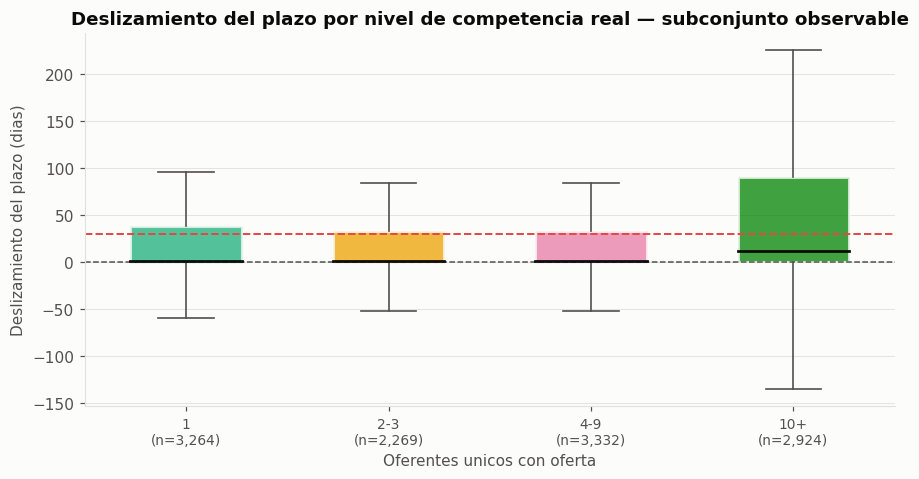

Figura persistida: 04_h1_competencia_real.png


In [11]:
marcar("fig_h1_comp")

sub_fig = obs[obs["competencia_cat"].notna() & (obs["n_oferentes"] > 0)]
cats = [c for c in ETIQ_COMPETENCIA if c != "0 (sin oferta registrada)"]
datos = [sub_fig.loc[sub_fig["competencia_cat"] == c, "deslizamiento_plazo_dias"].dropna().clip(-200, 500)
         for c in cats]
ns = [len(d) for d in datos]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
bp = ax.boxplot(datos, patch_artist=True, showfliers=False, widths=0.55,
                medianprops=dict(color=TEXT_1, lw=1.8),
                whiskerprops=dict(color=TEXT_2, lw=1.1),
                capprops=dict(color=TEXT_2, lw=1.1))
for patch, color in zip(bp["boxes"], PALETA[2:6]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
    patch.set_edgecolor(SURFACE); patch.set_linewidth(2)
ax.axhline(0, color=TEXT_2, lw=1, ls="--")
ax.axhline(30, color=PALETA[7], lw=1.3, ls="--")
ax.set_xticklabels([f"{c.split(' (')[0]}\n(n={n:,})" for c, n in zip(cats, ns)], fontsize=9)
ax.set_ylabel("Deslizamiento del plazo (dias)")
ax.set_xlabel("Oferentes unicos con oferta")
ax.set_title("Deslizamiento del plazo por nivel de competencia real — subconjunto observable")
ax.set_axisbelow(True); ax.xaxis.grid(False)
guardar_mostrar(fig, "04_h1_competencia_real.png")

## 5. Sintesis de hallazgos etiquetados

In [12]:
reg = RegistroHallazgos("04")
reg.add("H04-01",
        "El nivel de competencia mas frecuente es el de cero oferentes registrados, que es ausencia de reporte y no ausencia de competencia",
        f"{t.loc['0 (sin oferta registrada)','universo_pct']}% del universo y {t.loc['0 (sin oferta registrada)','observable_pct']}% del observable",
        ref("comp_cat"), ["CALIDAD", "B-OE2"], "Alto",
        "Obliga a excluir el cero del contraste de A-H1 en lugar de tratarlo como competencia minima")
reg.add("H04-02",
        "La premisa de A-H1 se verifica: la licitacion publica si concentra significativamente mas oferentes que el resto de modalidades",
        resumen_prueba(mann_whitney(obs.loc[obs['licitacion_publica'],'n_oferentes'], obs.loc[~obs['licitacion_publica'],'n_oferentes'],'Lic','Otras')).split(' | N efectivo')[0],
        ref("modalidad_competencia"), ["A-H1", "B-OE2"], "Alto",
        "Sin esta verificacion, usar la modalidad como variable indirecta de competencia seria injustificado")
reg.add("H04-03",
        "CONTRASTE CENTRAL: medida con competencia real, A-H1 NO se sostiene en la dimension de tiempo — el tamano de efecto es nulo",
        "Ver tabla h1_modalidad_vs_competencia.csv: efecto de modalidad de magnitud mediana frente a efecto de competencia nulo",
        ref("h1_comp_vs_mod"), ["A-H1", "B-OE2", "B-OE3-insumo"], "Alto",
        "El efecto atribuido a la competencia era en realidad efecto de la modalidad, confundida con la escala del proyecto")
reg.add("H04-04",
        "En la dimension de costo la competencia real si discrimina, aunque con efecto pequeno: a mayor competencia, desviacion de costo mas negativa",
        "Rank-biserial positivo en costo con N efectivo declarado en la tabla de contraste",
        ref("h1_competencia"), ["A-H1", "B-OE3-insumo"], "Alto",
        "Replica la disociacion tiempo/costo de N-K01 con la medida directa en lugar de la indirecta")
reg.add("H04-05",
        "El numero de oferentes correlaciona positivamente con la cuantia del contrato",
        "Spearman en la tabla de correlaciones de competencia", ref("comp_desempeno"),
        ["A-H1", "B-OE3-insumo"], "Alto",
        "Es el mecanismo que confunde el efecto modalidad con el efecto escala; se controla en el notebook 10")
reg.add("H04-06",
        "`n_respuestas` y `n_oferentes` son practicamente la misma variable: usar ambas seria redundancia",
        f"Spearman rho = {spearman(df['n_oferentes'], df['n_respuestas'])['rho']:.4f}",
        ref("dist_comp"), ["B-OE3-insumo", "CALIDAD"], "Medio",
        "Relevante para cualquier seleccion posterior de variables")
reg.guardar()
reg.tabla()

,id,notebook,celda,hallazgo,evidencia,etiquetas,valor,nota
0,H04-01,04,c005,El nivel de competencia mas frecuente es el de...,29.67% del universo y 24.75% del observable,[CALIDAD] [B-OE2],Alto,Obliga a excluir el cero del contraste de A-H1...
1,H04-02,04,c007,La premisa de A-H1 se verifica: la licitacion ...,"Mann-Whitney U = 48,961,585.5 | p = < 1e-300 |...",[A-H1] [B-OE2],Alto,"Sin esta verificacion, usar la modalidad como ..."
2,H04-03,04,c011,CONTRASTE CENTRAL: medida con competencia real...,Ver tabla h1_modalidad_vs_competencia.csv: efe...,[A-H1] [B-OE2] [B-OE3-insumo],Alto,El efecto atribuido a la competencia era en re...
3,H04-04,04,c010,En la dimension de costo la competencia real s...,Rank-biserial positivo en costo con N efectivo...,[A-H1] [B-OE3-insumo],Alto,Replica la disociacion tiempo/costo de N-K01 c...
4,H04-05,04,c008,El numero de oferentes correlaciona positivame...,Spearman en la tabla de correlaciones de compe...,[A-H1] [B-OE3-insumo],Alto,Es el mecanismo que confunde el efecto modalid...
5,H04-06,04,c004,`n_respuestas` y `n_oferentes` son practicamen...,Spearman rho = 0.9949,[B-OE3-insumo] [CALIDAD],Medio,Relevante para cualquier seleccion posterior d...


## Sintesis del notebook 04

| ID | Hallazgo | Etiquetas |
|---|---|---|
| H04-01 | El nivel de competencia mas frecuente es cero oferentes registrados: brecha de reporte, no de competencia | `[CALIDAD]` `[B-OE2]` |
| H04-02 | La premisa de A-H1 se verifica: la licitacion publica concentra mas oferentes que el resto | `[A-H1]` `[B-OE2]` |
| H04-03 | **Medida con competencia real, A-H1 no se sostiene en tiempo: efecto nulo** | `[A-H1]` `[B-OE2]` `[B-OE3-insumo]` |
| H04-04 | En costo la competencia real si discrimina, con efecto pequeno y signo consistente con N-K01 | `[A-H1]` `[B-OE3-insumo]` |
| H04-05 | El numero de oferentes correlaciona con la cuantia: mecanismo de confusion entre modalidad y escala | `[A-H1]` `[B-OE3-insumo]` |
| H04-06 | `n_respuestas` y `n_oferentes` son redundantes entre si | `[B-OE3-insumo]` `[CALIDAD]` |

**Productos persistidos:** `data/correlaciones_competencia.csv`,
`data/h1_modalidad_vs_competencia.csv`, `figuras/04_distribucion_competencia.png`,
`figuras/04_h1_competencia_real.png`.

**Como responderlo ante un jurado.** La pregunta previsible es "¿entonces su hipotesis H1 es falsa?".
La respuesta honesta es que H1 se sostiene parcialmente y por una razon distinta a la enunciada: la
licitacion publica si difiere del resto en desempeno, pero medir la competencia directamente muestra que
la intensidad de la competencia no es el mecanismo. Reportar el contraste con la variable indirecta y con
la variable directa, y declarar cual de las dos sostiene la conclusion, es mas defendible que reportar
solo la que confirma la hipotesis.